In [ ]:
"""Environment setup — run this cell first before any imports."""
import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "2"          # use GPU device 2; PyTorch sees it as cuda:0
#os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  # reduces fragmentation

import torch
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")
if device == "cuda":
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    free   = torch.cuda.mem_get_info()[0] / 1e9
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {free:.1f} GB free / {total:.1f} GB total")

Using device: cuda
GPU : NVIDIA RTX A5000
VRAM: 25.2 GB free / 25.4 GB total


# Notebook 02 — Feature Analysis
**Owner: Person B — Week 1–2**

Stage 2. Retrieve top-activating patches, auto-label with CLIP, compute Monosemanticity Scores, and produce the feature catalog.

Requires: activation cache built by Person C (cache.py + cache built in Colab).

## 1. Build / load activation cache

Run the first cell once to extract the zip and build the HDF5 cache (~10–20 min on MPS).
Skip it on subsequent runs — `build_cache` is guarded and won't overwrite an existing file.

Images come from two sources:
- `data/imagenet_val/imagenet_val_5000.zip` — 5,000 flat images, `label="unknown"` (for Week 1 Monosemanticity analysis)
- `data/imagenet_val/flamingo/` and `data/imagenet_val/spoonbill/` — labelled behaviour classes (for Week 2 causal analysis)

In [ ]:
"""Step 1a — extract zip and collect image paths (run once)."""
import zipfile
from pathlib import Path
from src.config import get_config
import src.config as _cfg_mod

cfg = get_config()
repo_root  = _cfg_mod._DEFAULT_CONFIG.parent.parent
data_dir   = repo_root / cfg.data.imagenet_val_path   # data/imagenet_val
zip_path   = repo_root / "data" / "imagenet_val_5000.zip"
cache_path = repo_root / cfg.outputs.cache_path

BEHAVIOR_CLASSES = {"flamingo": 130, "spoonbill": 129}

# --- 1. Extract zip if needed ---
# Zip contains imagenet_val/img_*.jpg → extracting to data/ yields data/imagenet_val/img_*.jpg
flat_dir = data_dir  # images live directly in data/imagenet_val/
if zip_path.exists() and not (flat_dir.exists() and any(flat_dir.glob("*.jpg"))):
    print(f"Extracting {zip_path.name} ...")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(repo_root / "data")
    print(f"Extracted {sum(1 for _ in flat_dir.glob('*.jpg'))} images -> {flat_dir}")
else:
    n = sum(1 for _ in flat_dir.glob("*.jpg")) if flat_dir.exists() else 0
    print(f"Flat images already extracted ({n} found)")

# --- 2. Collect paths + labels ---
image_paths, labels, class_ids = [], [], []

# 5000 flat images — no class metadata, label "unknown"
for p in sorted(flat_dir.glob("*.jpg")):
    image_paths.append(str(p.resolve()))
    labels.append("unknown")
    class_ids.append(-1)

# Labelled behaviour classes (needed by get_class_indices() in Week 2)
for cls_name, cls_id in BEHAVIOR_CLASSES.items():
    cls_dir = data_dir / cls_name
    if cls_dir.exists():
        for p in sorted(cls_dir.glob("*.JPEG")):
            image_paths.append(str(p.resolve()))
            labels.append(cls_name)
            class_ids.append(cls_id)

print(f"Total images : {len(image_paths)}")
print(f"  unknown    : {labels.count('unknown')}")
print(f"  flamingo   : {labels.count('flamingo')}")
print(f"  spoonbill  : {labels.count('spoonbill')}")

In [4]:
"""Step 1b — build cache (run once, ~10–20 min on MPS for 5000 images)."""
from src.cache import build_cache

if cache_path.exists():
    print(f"Cache already exists at {cache_path} — skipping build.")
    print("Delete the file and re-run if you want to rebuild.")
else:
    print(f"Building cache for {len(image_paths)} images, layers {cfg.sae.target_layers} ...")
    build_cache(image_paths, labels, class_ids, outputpath=str(cache_path))
    print(f"Done. Cache saved to {cache_path}")

Building cache for 5000 images, layers [4, 6, 9] ...


/home/gunaydin/miniconda3/envs/vit_mech/lib/python3.10/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.


2026-06-01 12:36:14 INFO:root: Model 'facebook/dino-vitb16' is supported and passes tests.
2026-06-01 12:36:14 DEBUG:httpcore.connection: connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
2026-06-01 12:36:14 DEBUG:httpcore.connection: connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x774ca5823640>
2026-06-01 12:36:14 DEBUG:httpcore.connection: start_tls.started ssl_context=<ssl.SSLContext object at 0x774ca581ce40> server_hostname='huggingface.co' timeout=10


ln_pre not set


2026-06-01 12:36:15 DEBUG:httpcore.http11: send_request_headers.started request=<Request [b'HEAD']>
2026-06-01 12:36:15 DEBUG:httpcore.http11: send_request_headers.complete
2026-06-01 12:36:15 DEBUG:httpcore.http11: send_request_body.started request=<Request [b'HEAD']>
2026-06-01 12:36:15 DEBUG:httpcore.http11: send_request_body.complete
2026-06-01 12:36:15 DEBUG:httpcore.http11: receive_response_headers.started request=<Request [b'HEAD']>
2026-06-01 12:36:15 DEBUG:httpcore.http11: receive_response_headers.complete return_value=(b'HTTP/1.1', 404, b'Not Found', [(b'Content-Type', b'text/plain; charset=utf-8'), (b'Content-Length', b'15'), (b'Connection', b'keep-alive'), (b'Date', b'Mon, 01 Jun 2026 10:36:15 GMT'), (b'ETag', b'W/"f-mY2VvLxuxB7KhsoOdQTlMTccuAQ"'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-6a1d609f-79e65c2b42a3df3274f45734;c5bc01dc-3a92-43b0-8213-11f6646e86ae'), (b'RateLimit', b'"resolvers";r=2987;t=167'), (b'RateLimit-Policy', b'"fixed window";"res

Loaded facebook/dino-vitb16 on cuda — 86,389,248 params


Building activation cache:   0%|          | 0/157 [00:00<?, ?it/s]

Done. Cache saved to /home/gunaydin/p3-vit-mech-interp/outputs/caches/activations.h5


In [5]:
"""Step 1c — load activations and image index from cache."""
from src.cache import load_layer, load_image_index, load_metadata

meta  = load_metadata(cachepath=str(cache_path))
index = load_image_index(cachepath=str(cache_path))
activations = load_layer(cfg.sae.primary_layer, cachepath=str(cache_path))

print(f"Model     : {meta['model_name']}")
print(f"Layers    : {meta['layers']}")
print(f"Images    : {meta['n_images']}")
print(f"activations shape : {tuple(activations.shape)}")  # (n_images, 197, 768)
print(f"Image paths sample: {index['paths'][:2]}")

2026-06-01 12:41:57 DEBUG:h5py._conv: Creating converter from 3 to 5


Model     : facebook/dino-vitb16
Layers    : [4, 6, 9]
Images    : 5000
activations shape : (5000, 197, 768)
Image paths sample: ['/home/gunaydin/p3-vit-mech-interp/data/imagenet_val/imagenet_val/img_0000.jpg', '/home/gunaydin/p3-vit-mech-interp/data/imagenet_val/imagenet_val/img_0001.jpg']


## 2. Top patches — single feature test

2026-06-01 12:42:23 INFO:root: get_activation_fn received: activation_fn=relu, kwargs={}


Loaded SAE layer 9 — d_in=768, d_sae=49152
Top 20 patches for feature 0:
  img 4026  token  12  row 0  col 11  activation 0.5814
  img 3189  token 181  row 12  col 12  activation 0.5279
  img  126  token  84  row 5  col 13  activation 0.4574


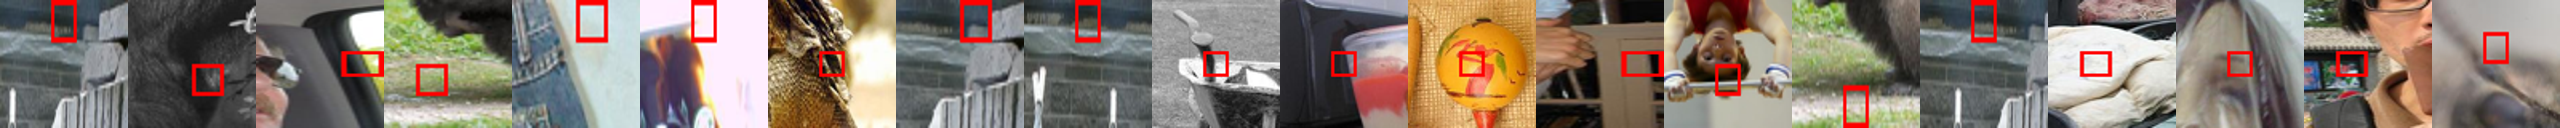

In [6]:
"""Single-feature smoke test — check one feature before running all 49k."""
import importlib, src.features
importlib.reload(src.features)
from src.features import get_top_patches, crop_patch_images

# Try feature 0 first; swap for any index in [0, sae.d_sae)
top = get_top_patches(
    layer=cfg.sae.primary_layer,
    feature_idx=0,
    activations=activations,
    image_paths=index["paths"],
)
print(f"Top {len(top)} patches for feature 0:")
for p in top[:3]:
    print(f"  img {p['image_idx']:4d}  token {p['token_idx']:3d}"
          f"  row {p['patch_row']}  col {p['patch_col']}"
          f"  activation {p['activation_value']:.4f}")

# Visual sanity check — display top patches with red box marking the active patch
crops = crop_patch_images(top, context_patches=2, mark_patch=True)
if crops:
    from PIL import Image as _PIL_Image
    row_img = _PIL_Image.new("RGB", (128 * len(crops), 128), "white")
    for i, c in enumerate(crops):
        row_img.paste(c.resize((128, 128)), (i * 128, 0))
    display(row_img)
else:
    print("No patch images to display (check image_paths resolve correctly).")

## 3. Top patches — all features

In [7]:
"""All features — streaming top-k, one GPU batch at a time.
Peak GPU memory ≈ batch_size × 197 × 49152 × 4 bytes:
  batch_size=32  → ~1.2 GB  (safe when < 4 GB free)
  batch_size=64  → ~2.4 GB  (safe when < 8 GB free)   ← default
  batch_size=128 → ~4.8 GB  (safe when < 8 GB free)
  batch_size=256 → ~9.5 GB  (only if GPU is mostly empty)
Check free VRAM in cell 1 output before choosing.
"""
import gzip, pickle
from pathlib import Path
from src.features import get_top_patches_all_features

feature_output_dir = repo_root / "outputs" / "features"
feature_output_dir.mkdir(parents=True, exist_ok=True)
top_patches_cache = feature_output_dir / f"top_patches_layer{cfg.sae.primary_layer}_full.pkl.gz"

if top_patches_cache.exists():
    with gzip.open(top_patches_cache, "rb") as _f:
        all_top_patches = pickle.load(_f)
    print(f"Loaded cached top patches: {top_patches_cache}")
else:
    all_top_patches = get_top_patches_all_features(
        cfg.sae.primary_layer,
        activations,
        index["paths"],
        batch_size=64,
    )
    with gzip.open(top_patches_cache, "wb") as _f:
        pickle.dump(all_top_patches, _f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved top patches → {top_patches_cache}")

# Remap image_path values in all_top_patches to local absolute paths.
# Needed when the pkl was built on a different machine (e.g. Colab) where
# the stored paths point to non-existent locations.
_name_to_local = {Path(p).name: p for p in image_paths}
for _patches in all_top_patches.values():
    for _p in _patches:
        _stored = Path(_p["image_path"])
        if not _stored.exists():
            _local = _name_to_local.get(_stored.name)
            if _local:
                _p["image_path"] = _local

print(f"Computed top patches for {len(all_top_patches)} features.")

Encoding batches:   0%|          | 0/79 [00:00<?, ?it/s]

Saved top patches → /home/gunaydin/p3-vit-mech-interp/outputs/features/top_patches_layer9_full.pkl.gz
Computed top patches for 49152 features.


## 4. CLIP auto-labeling

In [ ]:
"""CLIP auto-labeling — top-3 concept labels per feature.

Two-step flow for speed:
  Step 4a  Uses crop_clip_images: source image preprocessed to 224×224 via ImageOps.fit
           (matching model geometry), then a 96px context window around the activated
           patch is cropped and upscaled to 224px for CLIP — not the raw 16px patch token.

  Step 4b  Label all 49k features via embedding lookups — seconds per run.
           Re-run this step alone whenever you change vocab or top_n.
           Delete clip_labels_layer9_full.json to force relabeling.
"""
import importlib, src.features, utils.clip_vocab
importlib.reload(src.features)
importlib.reload(utils.clip_vocab)
from src.features import load_clip_labeler, precompute_patch_embeddings, label_features_clip
from utils.clip_vocab import get_vocab
import json

clip_model, processor = load_clip_labeler()

vocab = get_vocab()
print(f"Vocab: {len(vocab):,} concepts")

# ── Step 4a: precompute patch embeddings (run once per kernel session) ────────
if "patch_embeddings" not in dir():
    patch_embeddings = precompute_patch_embeddings(
        all_top_patches, clip_model, processor, batch_size=256
    )

# ── Step 4b: label all features (seconds with precomputed embeddings) ─────────
labels_cache = feature_output_dir / f"clip_labels_layer{cfg.sae.primary_layer}_full.json"

if labels_cache.exists():
    with open(labels_cache, encoding="utf-8") as _f:
        feature_labels = {int(k): v for k, v in json.load(_f).items()}
    print(f"Loaded cached CLIP labels: {labels_cache}")
else:
    feature_labels = label_features_clip(
        all_top_patches, vocab, clip_model, processor,
        top_n=3, patch_embeddings=patch_embeddings,
    )
    with open(labels_cache, "w", encoding="utf-8") as _f:
        json.dump({str(k): v for k, v in feature_labels.items()}, _f, indent=2)
    print(f"Saved CLIP labels → {labels_cache}")

print(f"\nLabelled {len(feature_labels):,} features.")
for fi in list(feature_labels)[:5]:
    print(f"  feature {fi:5d}: {feature_labels[fi]}")

2026-06-01 13:37:46 DEBUG:httpcore.connection: close.started
2026-06-01 13:37:46 DEBUG:httpcore.connection: close.complete
2026-06-01 13:37:46 DEBUG:httpcore.connection: connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
2026-06-01 13:37:46 DEBUG:httpcore.connection: connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x774c5a4b2140>
2026-06-01 13:37:46 DEBUG:httpcore.connection: start_tls.started ssl_context=<ssl.SSLContext object at 0x774ca581ce40> server_hostname='huggingface.co' timeout=10
2026-06-01 13:37:46 DEBUG:httpcore.connection: start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x774c5a4b1f60>
2026-06-01 13:37:46 DEBUG:httpcore.http11: send_request_headers.started request=<Request [b'HEAD']>
2026-06-01 13:37:46 DEBUG:httpcore.http11: send_request_headers.complete
2026-06-01 13:37:46 DEBUG:httpcore.http11: send_request_body.started request=<Request [b'HEAD']>
2026-06-01 1

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-06-01 13:37:48 DEBUG:httpcore.http11: send_request_headers.started request=<Request [b'GET']>
2026-06-01 13:37:48 DEBUG:httpcore.http11: send_request_headers.complete
2026-06-01 13:37:48 DEBUG:httpcore.http11: send_request_body.started request=<Request [b'GET']>
2026-06-01 13:37:48 DEBUG:httpcore.http11: send_request_body.complete
2026-06-01 13:37:48 DEBUG:httpcore.http11: receive_response_headers.started request=<Request [b'GET']>
2026-06-01 13:37:48 DEBUG:httpcore.http11: receive_response_headers.complete return_value=(b'HTTP/1.1', 404, b'Not Found', [(b'Content-Type', b'application/json; charset=utf-8'), (b'Content-Length', b'64'), (b'Connection', b'keep-alive'), (b'Date', b'Mon, 01 Jun 2026 11:37:48 GMT'), (b'ETag', b'W/"40-09f9IAqP13xarAhQxFS2W8rvRkM"'), (b'X-Powered-By', b'huggingface-moon'), (b'X-Request-Id', b'Root=1-6a1d6f0c-3ebaeee273ede985698205f2;5194f40a-3ed3-4940-87c8-84429821274c'), (b'RateLimit', b'"api";r=481;t=74'), (b'RateLimit-Policy', b'"fixed window";"api";q=

[vocab] Loaded 4030 labels from timm (1k base + 3030 targeted 21k additions) — Tier 4
[vocab] Total vocabulary: 4528 strings (tiers: [1, 2, 3, 4], tier4_subset: 'full')
Vocab: 4,528 concepts


CLIP labeling:   0%|          | 0/1536 [00:00<?, ?it/s]

Saved CLIP labels → /home/gunaydin/p3-vit-mech-interp/outputs/features/clip_labels_layer9_full.json

Labelled 49,152 features.
  feature     0: ['nape', 'close-up photograph', 'lacelike texture']
  feature     1: ['tuft', 'nutlet', 'extended neck']
  feature     2: ['side-blotched lizard', 'fringe-toed lizard', 'scaly texture']
  feature     3: ['lacelike texture', 'gauzy texture', 'loupe']
  feature     4: ['lacelike texture', 'eye', 'wall']


## 5. Monosemanticity Score distribution

In [18]:
"""Visual inspection — features filtered by max activation, sorted by median.

Only features with max_activation >= cfg.features.min_activation_threshold are shown.
From the activation distribution (cell above):
  max < 1.0  → ~37k features — weak signal, labels dominated by noise
  max >= 1.0 → ~12k features — clear activations, reliable labels
Sorted by median activation so stable features surface above one-off outliers.
"""
import statistics
from src.visualise import make_patch_grid

N_INSPECT         = 20
MIN_ACT_THRESHOLD = cfg.features.min_activation_threshold

eligible = {
    fi: patches
    for fi, patches in all_top_patches.items()
    if patches and patches[0]["activation_value"] >= MIN_ACT_THRESHOLD
}
print(f"Features above threshold {MIN_ACT_THRESHOLD}: {len(eligible):,} / {len(all_top_patches):,}")

top_features = sorted(
    eligible,
    key=lambda fi: statistics.median(p["activation_value"] for p in eligible[fi]),
    reverse=True,
)[:N_INSPECT]

inspect_patches = {fi: all_top_patches[fi] for fi in top_features}
grid = make_patch_grid(inspect_patches, labels=feature_labels, context_patches=2, crop_size=128)
display(grid)

In [ ]:
"""Monosemanticity Score — compute for all features and plot distribution.

Formula (Pach et al. 2025, Eq. 9):
  MS^k = Σ_{n<m} (ã^k_n · ã^k_m · s_{nm}) / Σ_{n<m} (ã^k_n · ã^k_m)
  s_{nm}  = CLIP cosine similarity between crop embeddings of patches n and m
  ã^k_n   = activation of feature k for patch n, min-max normalised to [0,1]

Uses cfg.features.ms_max_patches (top-5) not top-20: gives a wider, more
discriminating distribution because lower-ranked patches dilute the signal.
Requires patch_embeddings from cell 4a — run that cell first.
"""
import importlib, src.features, src.visualise
importlib.reload(src.features)
importlib.reload(src.visualise)
from src.features import compute_monosemanticity_score
from src.visualise import plot_monosemanticity_distribution
import json, math

MS_MAX_PATCHES = cfg.features.ms_max_patches

scores_cache = feature_output_dir / f"ms_scores_layer{cfg.sae.primary_layer}_top{MS_MAX_PATCHES}.json"

if scores_cache.exists():
    with open(scores_cache, encoding="utf-8") as _f:
        ms_scores = {int(k): v for k, v in json.load(_f).items()}
    print(f"Loaded cached MS scores: {scores_cache}")
else:
    ms_scores = compute_monosemanticity_score(
        all_top_patches, patch_embeddings,
        max_patches=MS_MAX_PATCHES,
    )
    with open(scores_cache, "w", encoding="utf-8") as _f:
        json.dump({str(k): v for k, v in ms_scores.items()}, _f)
    print(f"Saved MS scores → {scores_cache}")

alive = [v for v in ms_scores.values() if not math.isnan(v)]
dead  = sum(1 for v in ms_scores.values() if math.isnan(v))
print(f"Total features  : {len(ms_scores):,}")
print(f"Active features : {len(alive):,}")
print(f"Dead features   : {dead:,}  (nan — fewer than 2 activating patches)")
print(f"Median MS       : {sorted(alive)[len(alive)//2]:.3f}")
print(f"80th pct MS     : {sorted(alive)[int(len(alive)*0.8)]:.3f}")

figures_dir = repo_root / cfg.outputs.report_figures_path
figures_dir.mkdir(parents=True, exist_ok=True)

fig = plot_monosemanticity_distribution(
    ms_scores,
    layer=cfg.sae.primary_layer,
    save_path=str(figures_dir / f"ms_dist_layer{cfg.sae.primary_layer}_top{MS_MAX_PATCHES}.png"),
)
display(fig)

## 6. Feature gallery — top 50 by score

In [22]:
"""Feature gallery — top 50 features by Monosemanticity Score.

We do NOT use sorted(ms_scores)[:50] directly: the MS distribution has a spike
at exactly 1.0 dominated by low-support features (2-3 near-identical patches) —
a small-sample artefact of the Pach estimator, not true monosemanticity, and a
naive top-k pulls those straight to the top. So we filter first — requiring the
full ms_max_patches support and a real max activation — then rank survivors by
MS. This surfaces the right-shoulder (~0.65-0.90) features: high similarity
sustained across 5 distinct high-activation patches = the cleanest, most
nameable concepts, which feed the manual annotation in section 7.
"""
import importlib, src.visualise
importlib.reload(src.visualise)
from src.visualise import plot_feature_gallery
import math

MIN_ACTIVATION = cfg.features.min_activation_threshold
MIN_PATCHES    = cfg.features.ms_max_patches
TOP_N          = cfg.features.monosemanticity_top_n

# Support filter → drops the MS=1.0 artefact spike + weak-activation noise
eligible = []
for fi, score in ms_scores.items():
    if score is None or math.isnan(score):
        continue
    valid = [p for p in all_top_patches.get(fi, []) if p.get("patch_row") is not None]
    if len(valid) < MIN_PATCHES:
        continue
    if max((p["activation_value"] for p in valid), default=0.0) < MIN_ACTIVATION:
        continue
    eligible.append((fi, score))

eligible.sort(key=lambda kv: kv[1], reverse=True)
top_50 = [fi for fi, _ in eligible[:TOP_N]]

print(f"Support filter (>= {MIN_PATCHES} patches, max_act >= {MIN_ACTIVATION}): "
      f"{len(eligible):,} eligible → selected top {len(top_50)} by MS")
if top_50:
    print(f"MS range of selection: {ms_scores[top_50[0]]:.3f} (top) "
          f"… {ms_scores[top_50[-1]]:.3f} (#{len(top_50)})")

# feature_labels comes from cell 4 (CLIP labelling) if it has been run
_labels = feature_labels if "feature_labels" in dir() else None

fig = plot_feature_gallery(
    all_top_patches, top_50,
    labels=_labels,
    scores=ms_scores,
    max_patches=MIN_PATCHES,
    save_path=str(figures_dir / "feature_gallery.png"),
)
display(fig)
print(f"Saved → {figures_dir / 'feature_gallery.png'}")

## 7. Manual annotation

For each top-50 feature assign a category:
**texture / color / part / scene / semantic / unclear**

Save to `report/notes/feature_catalog_layer9.md`.

## Checkpoint
- [ ] Top patches look visually coherent
- [ ] CLIP labels sensible for >= 60% of inspected features
- [ ] Monosemanticity distribution plotted
- [ ] Top 50 features manually annotated
- [ ] feature_gallery.png saved to report/figures/